In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
print("Librerías importadas correctamente.")
    
url = "https://raw.githubusercontent.com/mricardo89/data-mining/main/Unit-II/datasets/titanic.csv"
df = pd.read_csv(url)

Librerías importadas correctamente.


# El Secuestro del Hiperplano
## El problema de la Escala

La escala del dinero es tan grande que "aplasta" a la variable de la edad en el espacio vectorial.

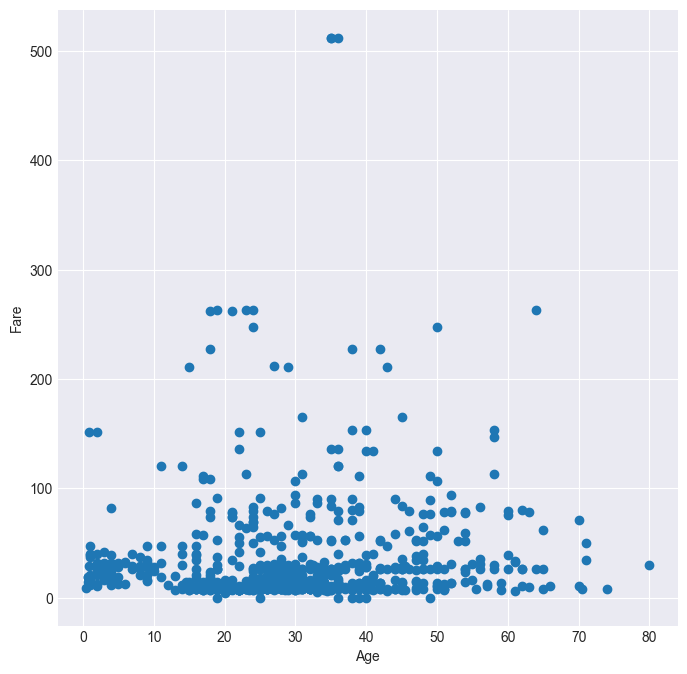

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(df["Age"], df["Fare"])
ax.set_xlabel("Age")
ax.set_ylabel("Fare")
# ax.set_aspect("equal", adjustable="box") # Descomentemos esta línea
plt.show()

## Un ejemplo específico

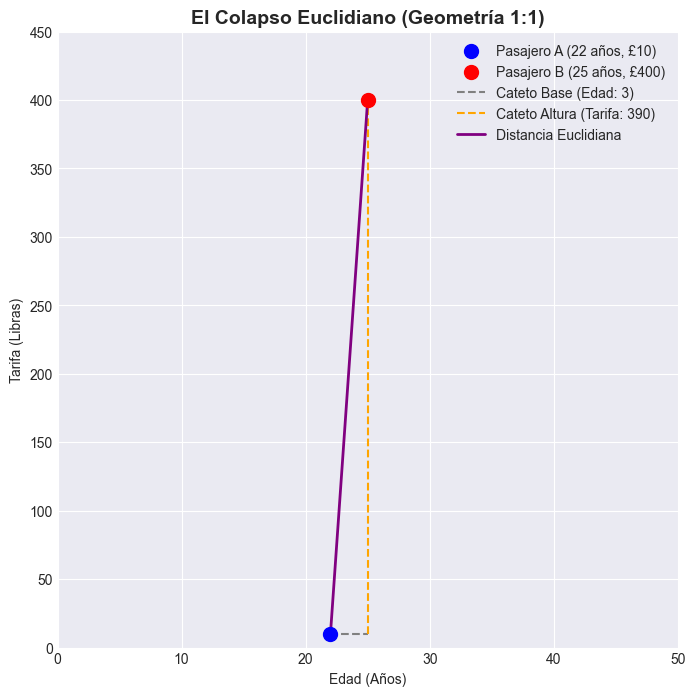

Distancia matemática calculada por el procesador: 390.01
Nota: El cateto de la Tarifa por sí solo mide 390. La Tarifa aportó casi el 100% de la distancia. La variable 'Edad' fue matemáticamente aniquilada.


In [4]:
# Coordenadas de los pasajeros (Edad, Tarifa)
A = np.array([22, 10])
B = np.array([25, 400])


fig, ax = plt.subplots(figsize=(8, 8))


ax.scatter(A[0], A[1], color='blue', s=100, label='Pasajero A (22 años, £10)', zorder=5)
ax.scatter(B[0], B[1], color='red', s=100, label='Pasajero B (25 años, £400)', zorder=5)


ax.plot([A[0], B[0]], [A[1], A[1]], color='gray', linestyle='--', label='Cateto Base (Edad: 3)')
ax.plot([B[0], B[0]], [A[1], B[1]], color='orange', linestyle='--', label='Cateto Altura (Tarifa: 390)')


ax.plot([A[0], B[0]], [A[1], B[1]], color='purple', linewidth=2, label='Distancia Euclidiana')


# ax.set_aspect('equal', adjustable='box')

ax.set_xlim(0, 50)
ax.set_ylim(0, 450)
ax.set_title("El Colapso Euclidiano (Geometría 1:1)", fontsize=14, fontweight='bold')
ax.set_xlabel("Edad (Años)")
ax.set_ylabel("Tarifa (Libras)")
ax.legend()
plt.show()


distancia = np.linalg.norm(B - A)
print(f"Distancia matemática calculada por el procesador: {distancia:.2f}")
print("Nota: El cateto de la Tarifa por sí solo mide 390. La Tarifa aportó casi el 100% de la distancia. La variable 'Edad' fue matemáticamente aniquilada.")

## El Cálculo de Demostración
Teorema de Pitágoras resolviendo la distancia para el algoritmo:
$$d = \sqrt{(\Delta X)^2 + (\Delta Y)^2}$$
$$d = \sqrt{(3)^2 + (390)^2}$$
$$d = \sqrt{9 + 152100}$$
$$d = \sqrt{152109} \approx 390.01$$

## Norma L2
Representa la distancia en línea recta desde el origen de coordenadas hasta el punto que define el vector, funcionando como el Teorema de Pitágoras generalizado a cualquier número de dimensiones.
$$\Vert X \Vert_2 = \sqrt{\sum_{i=1}^{N}(\Delta X_i) ^2}$$

---
###  El Cuchillo Lógico (`pd.cut`) vs. El Cuchillo Estadístico (`pd.qcut`)
A veces necesitamos convertir números continuos en categorías (*Binning* o Discretización). 
* `pd.cut()` corta la variable en distancias idénticas (ej. cada 20 años). Falla si los datos están sesgados, dejando grupos vacíos y otros repletos.
* `pd.qcut()` corta la variable basada en densidad (cuantiles). Garantiza que cada grupo tenga exactamente la misma cantidad de pasajeros, balanceando el modelo de Machine Learning.

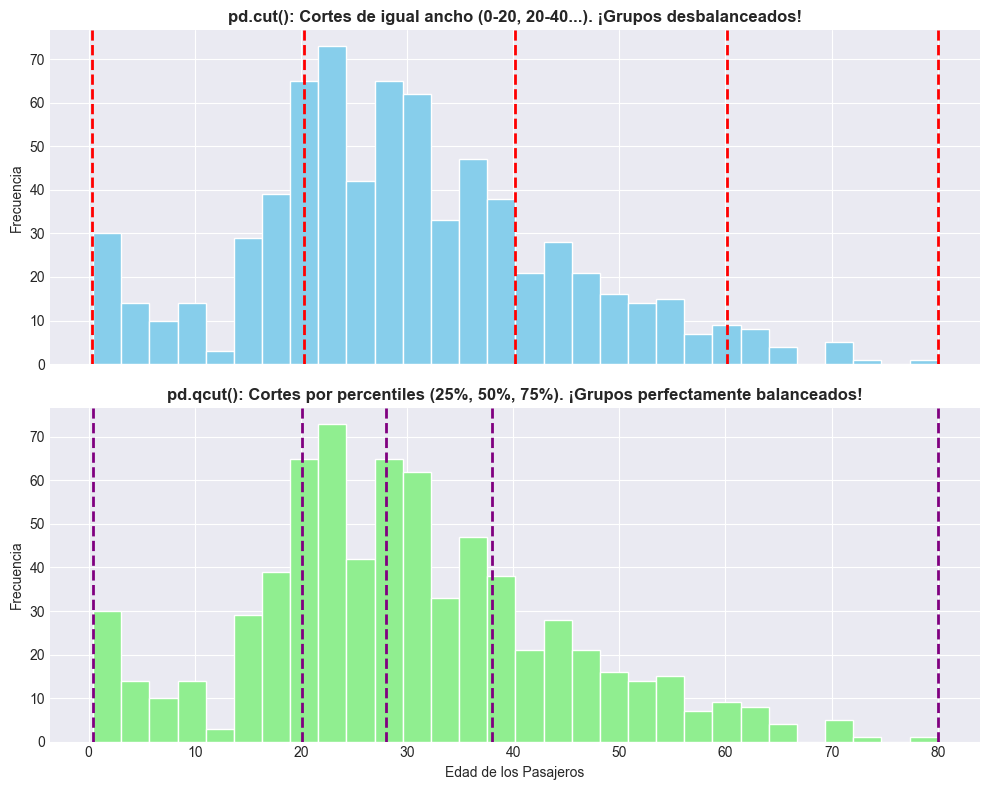

In [5]:
edades = df['Age']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 1. Gráfica para pd.cut (4 cortes de igual ancho)
ax1.hist(edades, bins=30, color='skyblue', edgecolor='white')
cortes_cut = pd.cut(edades, bins=4, retbins=True)[1] # Extraemos los límites matemáticos
for corte in cortes_cut:
    ax1.axvline(corte, color='red', linestyle='dashed', linewidth=2)
ax1.set_title("pd.cut(): Cortes de igual ancho (0-20, 20-40...). ¡Grupos desbalanceados!", fontweight='bold')
ax1.set_ylabel("Frecuencia")

# 2. Gráfica para pd.qcut (4 cortes de igual frecuencia / Cuartiles)
ax2.hist(edades, bins=30, color='lightgreen', edgecolor='white')
cortes_qcut = pd.qcut(edades, q=4, retbins=True)[1] # Extraemos los límites de los cuantiles
for corte in cortes_qcut:
    ax2.axvline(corte, color='purple', linestyle='dashed', linewidth=2)
ax2.set_title("pd.qcut(): Cortes por percentiles (25%, 50%, 75%). ¡Grupos perfectamente balanceados!", fontweight='bold')
ax2.set_xlabel("Edad de los Pasajeros")
ax2.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

---
## Experimentación: 
A partir de este punto, trabajarán en sus Notebooks. Aplicaremos transformaciones algebraicas para arreglar los problemas visuales que acabamos de descubrir.

### Pregunta A: Estandarización Z-Score (La Campana de Gauss)
Sabiendo que la columna `Age` no tiene outliers extremos biológicos (nadie tiene 500 años), estandarizaremos esta variable.
1. Crea una nueva columna llamada `Age_Z`.
2. Utilizando la vectorización de Pandas, aplica la fórmula matemática de Z-Score: $$(X - \mu) / \sigma$$.
3. Verifica que la nueva media sea prácticamente $0$ y la desviación estándar sea $1$.

In [6]:
# Escribe tu código aquí:
df['Age_Z'] = (df['Age'] - df['Age'].mean()) / df['Age'].std()

# Comprobación (Descomenta las siguientes líneas cuando termines):
print("Media estandarizada:", df['Age_Z'].mean())
print("Desviación estándar:", df['Age_Z'].std())

Media estandarizada: 2.388378943731429e-16
Desviación estándar: 0.9999999999999993


### Pregunta B: Normalización Min-Max (El Acotamiento Estricto)
1. Crea una nueva columna `Fare_MinMax` aplicando la fórmula $$(X - Min) / (Max - Min)$$ sobre la columna `Fare`.
2. Ejecuta un `.describe()` sobre esa nueva columna. 
3. **Análisis:** Al mirar el percentil 75% en tu `.describe()`, notarás que está muy cerca de `0.06`. Matemáticamente, ¿qué nos dice esto sobre cómo un solo pasajero millonario (el outlier de 512 libras) aplastó a toda la clase media trabajadora del barco?

In [ ]:
# Escribe tu código aquí:
df['Fare_MinMax'] = (df['Fare'] - df['Fare'].min()) / (df['Fare'].max() - df['Fare'].min())
df['Fare_MinMax'].describe()

count    891.000000
mean       0.062858
std        0.096995
min        0.000000
25%        0.015440
50%        0.028213
75%        0.060508
max        1.000000
Name: Fare_MinMax, dtype: float64

### Pregunta C: Discretización Lógica (El Cuchillo de Negocio `pd.cut`)
A un algoritmo de árboles de decisión a veces le sirve más la "Etapa de Vida" categórica que la edad decimal exacta.
1. Utiliza `pd.cut()` en la columna original `Age` para crear la columna `Age_Group`.
2. Usa estos cortes explícitos (bins): `0, 12, 18, 60, 100`.
3. Etiqueta (labels) los cortes como: `'Niño', 'Adolescente', 'Adulto', 'Anciano'`.
4. Muestra la cantidad de pasajeros por grupo. (Notarás el desbalance natural).

In [ ]:
# Escribe tu código aquí:
bins = [0, 12, 18, 60, 100]
labels = ["Niño", "Adolescente", "Adulto", "Anciano"]
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

print(df['Age_Group'].value_counts(sort=False))

Age_Group
Niño            69
Adolescente     70
Adulto         553
Anciano         22
Name: count, dtype: int64


Desde el punto de vista del negocio (biológico), nuestro código es perfecto y la base de datos es correcta: simplemente viajaban más adultos en el Titanic.

Pero desde el punto de vista del Machine Learning, acabamos de crear un problema masivo de 'Desbalance de Clases' (Class Imbalance).

### Pregunta D: Discretización Estadística Balanceada (El Cuchillo Estadístico `pd.qcut`)
Para evitar que el modelo se sesgue hacia las tarifas baratas (que son la mayoría), dividiremos las tarifas en 4 categorías "cuartiles", garantizando el mismo número de clientes en cada categoría para que la red neuronal no discrimine.
1. Utiliza `pd.qcut()` en la columna `Fare` para crear la nueva columna `Fare_Category` dividida en 4 partes iguales (`q=4`).
2. Muestra los conteos con `value_counts()`. Compara cómo este método sí balanceó la base de datos a diferencia del `cut()` biológico de la edad.

In [15]:
# Escribe tu código aquí:
df['Fare_Category'] = pd.qcut(df['Fare'], q=4)

print(df['Fare_Category'].value_counts(sort=False))

Fare_Category
(-0.001, 7.91]     223
(7.91, 14.454]     224
(14.454, 31.0]     222
(31.0, 512.329]    222
Name: count, dtype: int64


Miren la diferencia gráfica. La gráfica anterior era una montaña rusa; esta es completamente plana. Acabamos de lograr una Distribución Uniforme.

¿Cómo funciona este algoritmo bajo el capó? A diferencia de .cut() que divide el dinero en distancias fijas (ej. de 0 a 100 libras, de 100 a 200), .qcut() hace algo más inteligente: ordena a todos los pasajeros de menor a mayor tarifa, los cuenta (digamos que son 714), divide 714 entre 4 (lo que da ~178), y empieza a meter a 178 pasajeros en la primera caja, luego corta. Mete otros 178 en la segunda, y corta.